In [108]:
import csv
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
import json

from pmdarima import auto_arima
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [109]:
#with open('/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/data-new.json',"r") as file:
#    tree=json.load(file)
#nodes = pd.DataFrame(tree['nodes'])

In [110]:
#renaming the feature name to adapt previous codes.
#nodes = nodes.rename(columns={'subject': 'subject_code'})

In [111]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/version2_new_dataset_fitted.csv"
)

In [112]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   280203 non-null  float64
 9   subject_name                   280203 non-null  object 
 10  predicted_subject_code         130825 non-null  float64
 11  subject_prediction_confidence  136040 non-null  float64
 12  subject_prediction_vector     

In [113]:
nodes=nodes[(~nodes['subject_code'].isna())&(nodes['predicted_subject_code'].isna())]

In [114]:
nodes= nodes.drop('predicted_subject_code', axis=1)

In [115]:
nodes= nodes.drop(columns=['subject_prediction_confidence'])

In [116]:
nodes= nodes.drop(columns=['subject_prediction_vector'])

In [117]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202492 entries, 0 to 338531
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            202492 non-null  int64  
 1   name          202492 non-null  object 
 2   thesis        193399 non-null  object 
 3   school        166999 non-null  object 
 4   country       200557 non-null  object 
 5   year          167749 non-null  float64
 6   advisors      202492 non-null  object 
 7   students      202492 non-null  object 
 8   subject_code  202492 non-null  float64
 9   subject_name  202492 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 17.0+ MB


## 0. Data preparation

The matrices use subject codes as row labels, but `.iloc` selects by row position.  
For example, subject code 14 is currently at row position 9.

In [118]:
# Use annual data from 1960 through 2024.
years = np.arange(1960, 2024+1)

valid_pure = nodes[
    nodes["subject_code"].notna()
    & (nodes["subject_code"] < 61)
    & nodes["year"].between(1960, 2024+1)
].copy()

valid_pure["year"] = valid_pure["year"].astype(int)

codes_pure = np.sort(valid_pure["subject_code"].unique())

counts = (
    pd.crosstab(valid_pure["subject_code"], valid_pure["year"])
    .reindex(index=codes_pure, columns=years, fill_value=0)
)

year_totals = counts.sum(axis=0).replace(0, np.nan)
share = counts.div(year_totals, axis=1) * 100

print("counts shape:", counts.shape)
print("share shape:", share.shape)
print("Years with undefined shares:", share.columns[share.isna().any()].tolist())

counts shape: (44, 65)
share shape: (44, 65)
Years with undefined shares: []


In [119]:
# Select subject code 14 by first finding its row position.
subject_code = 14

matching_positions = np.flatnonzero(
    counts.index.to_numpy() == subject_code
)

if len(matching_positions) == 0:
    raise KeyError(f"Subject code {subject_code} is not present in counts.")

subject_row_position = int(matching_positions[0])

counts_subject14 = counts.iloc[subject_row_position].astype(float)
share_subject14 = share.iloc[subject_row_position].astype(float)
year_values = counts.columns.to_numpy(dtype=int)

print("Subject code:", subject_code)
print("Row position:", subject_row_position)
print("Row label at that position:", counts.index[subject_row_position])

Subject code: 14
Row position: 9
Row label at that position: 14.0


## 1. Forecasting models

In [ ]:
def forecast_models(train, train_years, forecast_years):
    """Fit all candidate models using one training fold."""

    train = np.asarray(train, dtype=float)
    train_years = np.asarray(train_years, dtype=float)
    forecast_years = np.asarray(forecast_years, dtype=float)
    horizon = len(forecast_years)

    forecasts = {}

    # 1. Simple exponential smoothing with fixed alpha.
    ses_model = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    ).fit(
        smoothing_level=0.5,
        optimized=False
    )
    forecasts["Simple exponential smoothing"] = np.asarray(
        ses_model.forecast(horizon),
        dtype=float
    )

    # 2. Ordinary Holt model, with parameters estimated inside the fold.
    holt_optimized = Holt(
        train,
        damped_trend=False,
        initialization_method="estimated"
    ).fit(optimized=True)
    forecasts["Holt optimized"] = np.asarray(
        holt_optimized.forecast(horizon),
        dtype=float
    )

    # 3. Damped Holt model, with parameters estimated inside the fold.
    holt_damped = Holt(
        train,
        damped_trend=True,
        initialization_method="estimated"
    ).fit(optimized=True)
    forecasts["Holt damped"] = np.asarray(
        holt_damped.forecast(horizon),
        dtype=float
    )

    # 4. Linear trend fitted only on the years in this training fold.
    linear_model = LinearRegression()
    linear_model.fit(train_years.reshape(-1, 1), train)
    forecasts["Linear trend"] = linear_model.predict(
        forecast_years.reshape(-1, 1)
    )

    # 5. Fixed ARIMA(0, 1, 1).
    arima_011_model = pm.ARIMA(
        order=(0, 1, 1),
        with_intercept=False,
        suppress_warnings=True
    ).fit(train)
    forecasts["ARIMA(0,1,1)"] = np.asarray(
        arima_011_model.predict(n_periods=horizon),
        dtype=float
    )

    # 6. Auto-ARIMA.
    auto_model = auto_arima(
        train,
        start_p=0,
        start_q=0,
        max_p=3,
        max_q=3,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=False
    )
    forecasts["Auto ARIMA"] = np.asarray(
        auto_model.predict(n_periods=horizon),
        dtype=float
    )

    return forecasts

## 2. Rolling-window cross-validation

In [121]:
def rolling_window_cv(
    y,
    year_values,
    window_size=20,
    horizon=3,
    step=3
):
    """Run fixed-length rolling-window time-series cross-validation.

    Returns
    -------
    metrics : pandas.DataFrame
        One row per fold and model.
    forecast_details : pandas.DataFrame
        One row per forecasted year and model.
    """

    y = np.asarray(y, dtype=float)
    year_values = np.asarray(year_values)

    if len(y) != len(year_values):
        raise ValueError("y and year_values must have the same length.")

    if window_size < 2:
        raise ValueError("window_size must be at least 2.")

    if horizon < 1 or step < 1:
        raise ValueError("horizon and step must be positive.")

    if window_size + horizon > len(y):
        raise ValueError(
            "window_size + horizon cannot exceed the series length."
        )

    if np.isnan(y).any():
        missing_years = year_values[np.isnan(y)]
        raise ValueError(
            f"The series contains missing values in years "
            f"{missing_years.tolist()}."
        )

    metric_records = []
    forecast_records = []
    fold_number = 0

    for test_start in range(
        window_size,
        len(y) - horizon + 1,
        step
    ):
        fold_number += 1

        train_start = test_start - window_size
        test_end = test_start + horizon

        train = y[train_start:test_start]
        test = y[test_start:test_end]

        train_years = year_values[train_start:test_start]
        test_years = year_values[test_start:test_end]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            forecasts = forecast_models(
                train=train,
                train_years=train_years,
                forecast_years=test_years
            )

        mase_scale = np.mean(np.abs(np.diff(train)))

        for model_name, prediction in forecasts.items():
            prediction = np.asarray(prediction, dtype=float)

            if len(prediction) != len(test):
                raise ValueError(
                    f"{model_name} returned {len(prediction)} predictions "
                    f"for a test set of length {len(test)}."
                )

            fold_mse = mean_squared_error(test, prediction)
            fold_mae = mean_absolute_error(test, prediction)

            metric_records.append({
                "fold": fold_number,
                "model": model_name,
                "train_start": int(train_years[0]),
                "train_end": int(train_years[-1]),
                "test_start": int(test_years[0]),
                "test_end": int(test_years[-1]),
                "MSE": fold_mse,
                "RMSE": np.sqrt(fold_mse),
                "MAE": fold_mae,
                "MASE": (
                    fold_mae / mase_scale
                    if mase_scale > 0
                    else np.nan
                )
            })

            for year, actual, predicted in zip(
                test_years,
                test,
                prediction
            ):
                forecast_records.append({
                    "fold": fold_number,
                    "model": model_name,
                    "year": int(year),
                    "actual": float(actual),
                    "predicted": float(predicted),
                    "error": float(actual - predicted)
                })

    metrics = pd.DataFrame(metric_records)
    forecast_details = pd.DataFrame(forecast_records)

    return metrics, forecast_details

In [122]:
def summarize_cv_results(cv_metrics):
    """Average the error measures across validation folds."""

    if cv_metrics.empty:
        return pd.DataFrame()

    return (
        cv_metrics
        .groupby("model")
        .agg(
            mean_MSE=("MSE", "mean"),
            std_MSE=("MSE", "std"),
            mean_RMSE=("RMSE", "mean"),
            mean_MAE=("MAE", "mean"),
            mean_MASE=("MASE", "mean"),
            number_of_folds=("fold", "nunique")
        )
        .sort_values("mean_MSE")
    )

## 3. Subject 14: five-year rolling forecasts

With `window_size=40`, `horizon=5`, and `step=5`, every fold trains on exactly 40 years and predicts the next 5 years.

In [123]:
counts_rolling_metrics, counts_rolling_forecasts = rolling_window_cv(
    y=counts_subject14.to_numpy(),
    year_values=year_values,
    window_size=20,
    horizon=3,
    step=3
)

counts_rolling_summary = summarize_cv_results(
    counts_rolling_metrics
)
counts_rolling_summary

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Holt damped,251.550361,306.139578,12.854233,11.409804,1.559658,15
Holt optimized,290.178002,359.238212,13.522012,12.103281,1.587511,15
Simple exponential smoothing,307.492468,402.992267,14.479589,12.948279,1.877961,15
Auto ARIMA,327.734628,479.234708,14.264787,12.951156,1.702090,15
Linear trend,422.080488,611.196039,15.776725,14.436341,1.851054,15
"ARIMA(0,0,2)",5663.594551,6569.126730,60.858440,55.756174,7.029280,15


In [124]:
share_rolling_metrics, share_rolling_forecasts = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=20,
    horizon=3,
    step=3
)

share_rolling_summary = summarize_cv_results(
    share_rolling_metrics
)
share_rolling_summary

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Linear trend,0.679495,0.909284,0.720845,0.609812,0.684986,15
Holt optimized,0.679496,0.909284,0.720846,0.609812,0.684986,15
Holt damped,0.706895,1.036681,0.728582,0.617880,0.694024,15
Simple exponential smoothing,0.956946,1.501425,0.837015,0.717447,0.803512,15
Auto ARIMA,1.231024,1.659065,0.964498,0.833842,0.895978,15
"ARIMA(0,0,2)",21.233398,12.693762,4.436977,4.126925,4.940084,15


### 3.1 Error by rolling fold

In [125]:
share_rolling_metrics.pivot(
    index="fold",
    columns="model",
    values="MSE"
)

model,"ARIMA(0,0,2)",Auto ARIMA,Holt damped,Holt optimized,Linear trend,Simple exponential smoothing
fold,,,,,,
1,5.046986,0.536251,0.635509,0.407128,0.407128,0.501067
2,24.138954,6.791065,4.320917,3.782322,3.782321,6.219436
3,15.567325,1.885574,0.293693,0.288229,0.288229,0.428887
4,14.651934,0.992789,0.109869,0.102954,0.102953,0.558018
5,8.484636,0.378994,0.509915,0.536691,0.536686,0.338244
6,23.766506,1.747257,0.524932,0.558773,0.558773,0.877548
7,18.213790,0.667008,0.371978,0.418402,0.418402,0.402233
8,13.392094,1.626089,0.591751,1.019878,1.019878,0.863513
9,12.272425,0.496588,0.159057,0.160940,0.160939,0.154808


### 3.2 Plot rolling forecasts

In [126]:
def plot_cv_forecasts(
    original_series,
    year_values,
    cv_forecasts,
    model_name,
    title
):
    plt.figure(figsize=(16, 7))

    plt.plot(
        year_values,
        original_series,
        label="Actual series",
        linewidth=2
    )

    selected = cv_forecasts[
        cv_forecasts["model"] == model_name
    ]

    for fold in selected["fold"].unique():
        fold_data = selected[selected["fold"] == fold]

        plt.plot(
            fold_data["year"],
            fold_data["predicted"],
            marker="o",
            linestyle="--",
            alpha=0.8
        )

    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.show()

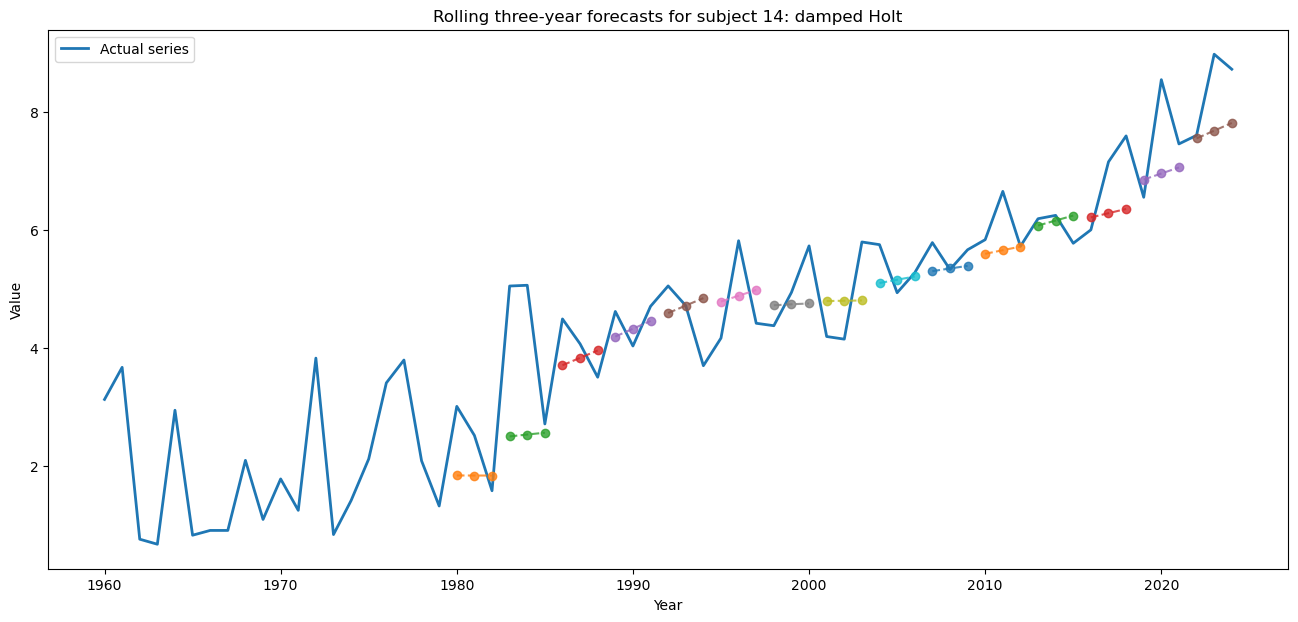

In [127]:
plot_cv_forecasts(
    original_series=share_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=share_rolling_forecasts,
    model_name="Holt damped",
    title=(
        "Rolling three-year forecasts for subject 14: "
        "damped Holt"
    )
)

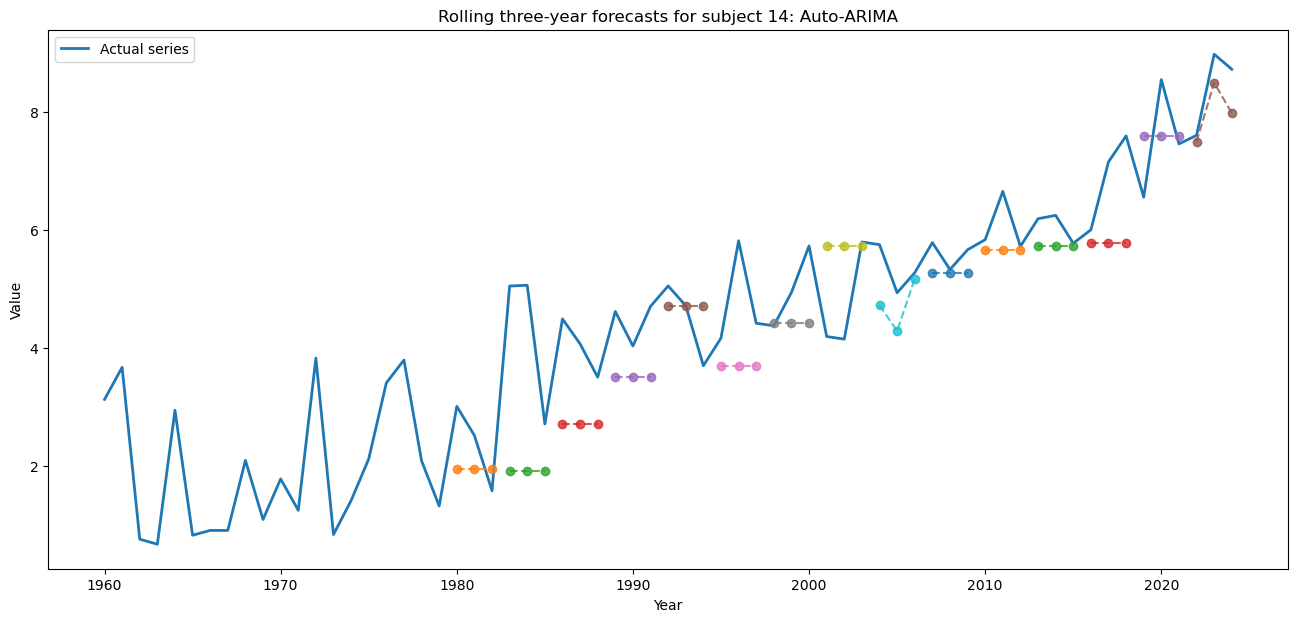

In [128]:
plot_cv_forecasts(
    original_series=share_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=share_rolling_forecasts,
    model_name="Auto ARIMA",
    title=(
        "Rolling three-year forecasts for subject 14: "
        "Auto-ARIMA"
    )
)

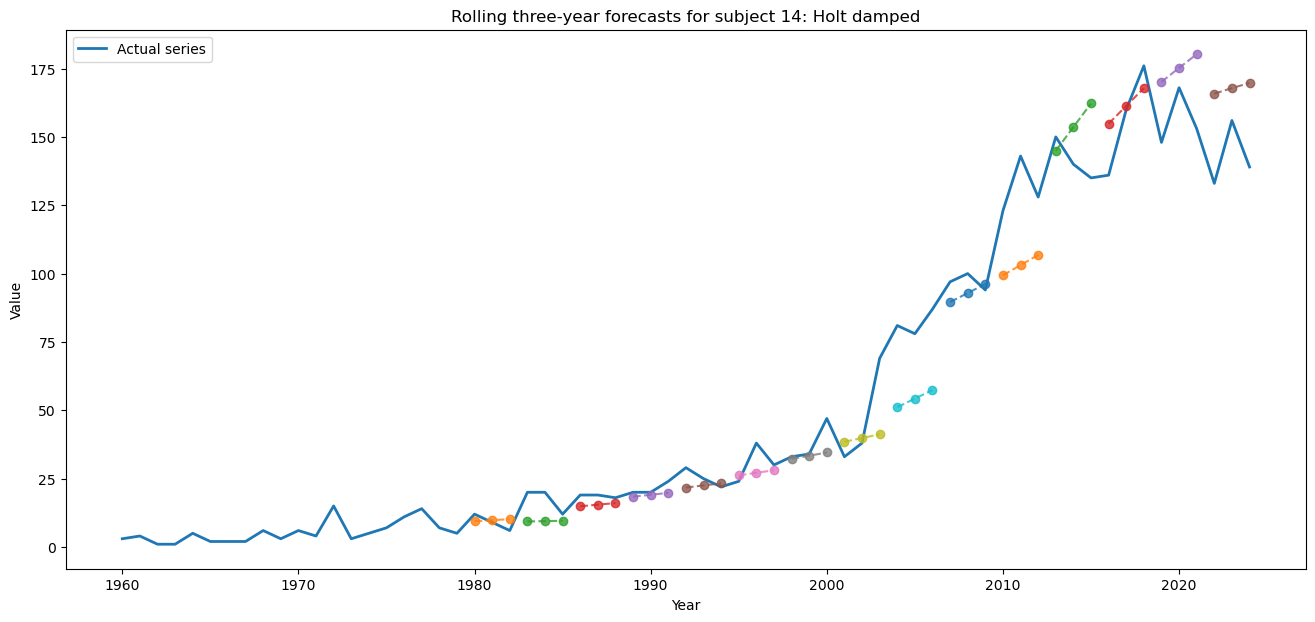

In [129]:
plot_cv_forecasts(
    original_series=counts_subject14.to_numpy(),
    year_values=year_values,
    cv_forecasts=counts_rolling_forecasts,
    model_name="Holt damped",
    title=(
        "Rolling three-year forecasts for subject 14: "
        "Holt damped"
    )
)

In [130]:
share_subject14

year
1960    3.125000
1961    3.669725
1962    0.751880
1963    0.666667
1964    2.941176
          ...   
2020    8.553971
2021    7.463415
2022    7.608696
2023    8.986175
2024    8.731156
Name: 14.0, Length: 65, dtype: float64

## 4. One-year versus five-year rolling forecasts

In [131]:
share_cv_1year, share_forecasts_1year = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=20,
    horizon=1,
    step=1
)

share_summary_1year = summarize_cv_results(
    share_cv_1year
)
share_summary_1year

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Holt damped,0.696889,1.189441,0.624937,0.624937,0.707683,45
Holt optimized,0.705060,1.094300,0.647999,0.647999,0.728497,45
Linear trend,0.711682,1.091186,0.655937,0.655937,0.740228,45
Simple exponential smoothing,0.836019,1.488496,0.694422,0.694422,0.796761,45
Auto ARIMA,1.057598,1.757610,0.811296,0.811296,0.926331,45
"ARIMA(0,0,2)",6.071558,6.499396,2.107460,2.107460,2.545690,45


In [132]:
share_cv_5year, share_forecasts_5year = rolling_window_cv(
    y=share_subject14.to_numpy(),
    year_values=year_values,
    window_size=40,
    horizon=5,
    step=5
)

share_summary_5year = summarize_cv_results(
    share_cv_5year
)
share_summary_5year

,mean_MSE,std_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
model,,,,,,
Auto ARIMA,0.428221,0.418433,0.585820,0.489425,0.547280,5
Linear trend,0.689799,0.745258,0.750192,0.686898,0.769533,5
Holt optimized,0.689799,0.745259,0.750192,0.686898,0.769533,5
Simple exponential smoothing,0.890901,0.920810,0.848892,0.763994,0.858067,5
Holt damped,0.973997,1.293711,0.839401,0.755129,0.859153,5
"ARIMA(0,0,2)",33.304403,14.716930,5.668043,5.445934,6.031165,5


## 5. Rolling cross-validation for all subjects

In [133]:
def cross_validate_all_subjects(
    matrix,
    window_size=20,
    horizon=3,
    step=3
):
    """Run rolling-window CV on every row of a subject matrix."""

    all_results = []
    failed_subjects = []

    matrix_years = matrix.columns.to_numpy(dtype=int)

    for row_position in range(matrix.shape[0]):
        subject_code = matrix.index[row_position]
        y = matrix.iloc[row_position].astype(float)

        print(
            f"Processing row {row_position}, "
            f"subject code {subject_code}"
        )

        try:
            metrics, _ = rolling_window_cv(
                y=y.to_numpy(),
                year_values=matrix_years,
                window_size=window_size,
                horizon=horizon,
                step=step
            )

            metrics["row_position"] = row_position
            metrics["subject_code"] = subject_code
            all_results.append(metrics)

        except Exception as error:
            failed_subjects.append({
                "row_position": row_position,
                "subject_code": subject_code,
                "error": str(error)
            })
            print(
                f"Subject code {subject_code} failed: {error}"
            )

    if all_results:
        results = pd.concat(
            all_results,
            ignore_index=True
        )
    else:
        results = pd.DataFrame()

    failures = pd.DataFrame(failed_subjects)

    return results, failures

In [134]:
def summarize_models_by_subject(all_cv_results):
    """Summarize each model separately for every subject."""

    if all_cv_results.empty:
        return pd.DataFrame()

    return (
        all_cv_results
        .groupby(
            ["row_position", "subject_code", "model"]
        )
        .agg(
            mean_MSE=("MSE", "mean"),
            mean_RMSE=("RMSE", "mean"),
            mean_MAE=("MAE", "mean"),
            mean_MASE=("MASE", "mean"),
            number_of_folds=("fold", "nunique")
        )
        .reset_index()
    )


def select_best_model_by_subject(subject_model_summary):
    """Choose the lowest-mean-MSE model for each subject."""

    if subject_model_summary.empty:
        return pd.DataFrame()

    return (
        subject_model_summary
        .sort_values(
            ["subject_code", "mean_MSE"]
        )
        .groupby("subject_code", as_index=False)
        .first()
    )

### 5.1 Percentage series for all subjects

In [135]:
all_share_cv_results, share_cv_failures = cross_validate_all_subjects(
    matrix=share,
    window_size=20,
    horizon=3,
    step=3
)

print("Failed share series:", len(share_cv_failures))
share_cv_failures.head()

Processing row 0, subject code 0.0
Processing row 1, subject code 1.0
Processing row 2, subject code 3.0
Processing row 3, subject code 5.0
Processing row 4, subject code 6.0
Processing row 5, subject code 8.0
Processing row 6, subject code 11.0
Processing row 7, subject code 12.0
Processing row 8, subject code 13.0
Processing row 9, subject code 14.0
Processing row 10, subject code 15.0
Processing row 11, subject code 16.0
Processing row 12, subject code 17.0
Processing row 13, subject code 18.0
Processing row 14, subject code 19.0
Processing row 15, subject code 20.0
Processing row 16, subject code 22.0
Processing row 17, subject code 26.0
Processing row 18, subject code 28.0
Processing row 19, subject code 30.0
Processing row 20, subject code 31.0
Processing row 21, subject code 32.0
Processing row 22, subject code 33.0
Processing row 23, subject code 34.0
Processing row 24, subject code 35.0
Processing row 25, subject code 37.0
Processing row 26, subject code 39.0
Processing row 27

""


In [136]:
share_subject_model_summary = summarize_models_by_subject(
    all_share_cv_results
)

share_best_model_by_subject = select_best_model_by_subject(
    share_subject_model_summary
)

share_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0.0,0,Holt damped,0.304357,0.478268,0.412191,0.888437,15
1,1.0,1,Auto ARIMA,0.075400,0.245889,0.216082,0.616323,15
2,3.0,2,Holt damped,1.554931,0.997581,0.869384,0.647308,15
3,5.0,3,Holt optimized,0.945420,0.912139,0.823946,0.748095,15
4,6.0,4,Holt damped,0.135107,0.307301,0.268889,0.595491,15
5,8.0,5,Holt damped,0.067738,0.237046,0.212241,0.586826,15
6,11.0,6,Simple exponential smoothing,0.989970,0.901035,0.757021,0.751479,15
7,12.0,7,Holt damped,0.032968,0.172774,0.153553,0.545279,15
8,13.0,8,Auto ARIMA,0.241939,0.436603,0.397501,0.706785,15
9,14.0,9,Linear trend,0.679495,0.720845,0.609812,0.684986,15


### 5.2 Count series for all subjects

In [137]:
all_counts_cv_results, counts_cv_failures = cross_validate_all_subjects(
    matrix=counts,
    window_size=20,
    horizon=3,
    step=3
)

print("Failed count series:", len(counts_cv_failures))
counts_cv_failures.head()

Processing row 0, subject code 0.0
Processing row 1, subject code 1.0
Processing row 2, subject code 3.0
Processing row 3, subject code 5.0
Processing row 4, subject code 6.0
Processing row 5, subject code 8.0
Processing row 6, subject code 11.0
Processing row 7, subject code 12.0
Processing row 8, subject code 13.0
Processing row 9, subject code 14.0
Processing row 10, subject code 15.0
Processing row 11, subject code 16.0
Processing row 12, subject code 17.0
Processing row 13, subject code 18.0
Processing row 14, subject code 19.0
Processing row 15, subject code 20.0
Processing row 16, subject code 22.0
Processing row 17, subject code 26.0
Processing row 18, subject code 28.0
Processing row 19, subject code 30.0
Processing row 20, subject code 31.0
Processing row 21, subject code 32.0
Processing row 22, subject code 33.0
Processing row 23, subject code 34.0
Processing row 24, subject code 35.0
Processing row 25, subject code 37.0
Processing row 26, subject code 39.0
Processing row 27

""


In [138]:
counts_subject_model_summary = summarize_models_by_subject(
    all_counts_cv_results
)

counts_best_model_by_subject = select_best_model_by_subject(
    counts_subject_model_summary
)

counts_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,0.0,0,Holt optimized,42.523031,5.642949,5.030354,1.480012,15
1,1.0,1,Simple exponential smoothing,6.619247,2.372218,2.052646,1.063488,15
2,3.0,2,Simple exponential smoothing,150.733667,10.938444,9.602809,1.229434,15
3,5.0,3,Holt optimized,571.912754,18.200243,17.191717,1.827860,15
4,6.0,4,Holt damped,13.069558,3.275454,2.905338,1.018955,15
5,8.0,5,Holt damped,6.940501,2.235358,2.056998,0.947745,15
6,11.0,6,Simple exponential smoothing,528.191822,17.934494,16.473124,2.012756,15
7,12.0,7,Simple exponential smoothing,5.082526,2.004520,1.752345,0.942672,15
8,13.0,8,Auto ARIMA,47.157920,6.005723,5.083705,1.327809,15
9,14.0,9,Holt damped,251.550361,12.854233,11.409804,1.559658,15


## 6. Selection for the best model

In [139]:
def model_vote_summary(
    subject_model_summary,
    metric="mean_MSE",
    tie_tolerance=1e-12
):
    """
    Give each subject one total vote to the model(s) with the lowest error.

    If multiple models tie for one subject, that subject's vote is divided
    equally among the tied models.

    Parameters
    ----------
    subject_model_summary : pandas.DataFrame
        Output from summarize_models_by_subject().

    metric : str
        Metric used to select the best model for each subject.
        Examples: "mean_MSE", "mean_RMSE", "mean_MAE", "mean_MASE".

    tie_tolerance : float
        Numerical tolerance used when detecting ties.

    Returns
    -------
    subject_votes : pandas.DataFrame
        Winning model(s) and assigned vote for every subject.

    vote_summary : pandas.DataFrame
        Total votes and vote percentages for every model.
    """

    required_columns = {
        "row_position",
        "subject_code",
        "model",
        metric
    }

    missing_columns = required_columns.difference(
        subject_model_summary.columns
    )

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    results = (
        subject_model_summary
        .dropna(subset=[metric])
        .copy()
    )

    if results.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Best score for each subject
    results["best_score_for_subject"] = (
        results
        .groupby("subject_code")[metric]
        .transform("min")
    )

    # Keep every model tied for the best score
    subject_votes = results[
        np.isclose(
            results[metric],
            results["best_score_for_subject"],
            rtol=tie_tolerance,
            atol=tie_tolerance
        )
    ].copy()

    # Divide one subject's vote equally if there is a tie
    subject_votes["number_of_tied_models"] = (
        subject_votes
        .groupby("subject_code")["model"]
        .transform("count")
    )

    subject_votes["vote"] = (
        1 / subject_votes["number_of_tied_models"]
    )

    subject_votes = subject_votes[
        [
            "row_position",
            "subject_code",
            "model",
            metric,
            "number_of_tied_models",
            "vote"
        ]
    ].sort_values(
        ["subject_code", "model"]
    )

    number_of_subjects = (
        results["subject_code"].nunique()
    )

    # Include models that received zero votes
    all_models = pd.DataFrame({
        "model": sorted(results["model"].unique())
    })

    vote_summary = (
        subject_votes
        .groupby("model", as_index=False)
        .agg(
            total_votes=("vote", "sum"),
            subjects_with_win=("subject_code", "nunique")
        )
    )

    vote_summary = (
        all_models
        .merge(
            vote_summary,
            on="model",
            how="left"
        )
        .fillna(
            {
                "total_votes": 0,
                "subjects_with_win": 0
            }
        )
    )

    vote_summary["vote_percentage"] = (
        100
        * vote_summary["total_votes"]
        / number_of_subjects
    )

    vote_summary["rank"] = (
        vote_summary["total_votes"]
        .rank(
            method="dense",
            ascending=False
        )
        .astype(int)
    )

    vote_summary["number_of_subjects"] = number_of_subjects

    vote_summary = vote_summary[
        [
            "rank",
            "model",
            "total_votes",
            "vote_percentage",
            "subjects_with_win",
            "number_of_subjects"
        ]
    ].sort_values(
        ["rank", "model"]
    ).reset_index(drop=True)

    return subject_votes, vote_summary


# ============================================================
# Count-series voting
# ============================================================

counts_subject_votes, counts_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=counts_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for count series:")
display(counts_model_vote_summary)

counts_selected_model = (
    counts_model_vote_summary.iloc[0]["model"]
    if not counts_model_vote_summary.empty
    else None
)

print("Selected count-series model:", counts_selected_model)


# ============================================================
# Share-series voting
# ============================================================

share_subject_votes, share_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=share_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for share series:")
display(share_model_vote_summary)

share_selected_model = (
    share_model_vote_summary.iloc[0]["model"]
    if not share_model_vote_summary.empty
    else None
)

print("Selected share-series model:", share_selected_model)

Model voting results for count series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,Simple exponential smoothing,22.0,50.000000,22.0,44
1,2,Holt optimized,11.0,25.000000,11.0,44
2,3,Holt damped,6.0,13.636364,6.0,44
3,4,Auto ARIMA,4.0,9.090909,4.0,44
4,5,Linear trend,1.0,2.272727,1.0,44
5,6,"ARIMA(0,0,2)",0.0,0.000000,0.0,44


Selected count-series model: Simple exponential smoothing
Model voting results for share series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,Holt damped,14.0,31.818182,14.0,44
1,2,Simple exponential smoothing,12.0,27.272727,12.0,44
2,3,Auto ARIMA,11.0,25.000000,11.0,44
3,4,Linear trend,5.0,11.363636,5.0,44
4,5,Holt optimized,2.0,4.545455,2.0,44
5,6,"ARIMA(0,0,2)",0.0,0.000000,0.0,44


Selected share-series model: Holt damped


In [140]:
# Preserve the pure-math matrices and selected models
# before counts, share, and selected-model variables are overwritten.

counts_pure = counts.copy()
share_pure = share.copy()

pure_counts_selected_model = counts_selected_model
pure_share_selected_model = share_selected_model

print("Pure-math count model:", pure_counts_selected_model)
print("Pure-math share model:", pure_share_selected_model)

Pure-math count model: Simple exponential smoothing
Pure-math share model: Holt damped


## 7. Applied math 

We apply all the previous analysis to all applied math subjects:

In [141]:
#we overwrite `counts` and `share` using applied math subjects
years = np.arange(1960, 2024+1)

valid_applied = nodes[
    nodes["subject_code"].notna()
    & (nodes["subject_code"] > 61)
    & nodes["year"].between(1960, 2024+1)
].copy()

valid_applied["year"] = valid_applied["year"].astype(int)

codes_applied = np.sort(valid_applied["subject_code"].unique())

counts = (
    pd.crosstab(valid_applied["subject_code"], valid_applied["year"])
    .reindex(index=codes_applied, columns=years, fill_value=0)
)

year_totals = counts.sum(axis=0).replace(0, np.nan)
share = counts.div(year_totals, axis=1) * 100

print("counts shape:", counts.shape)
print("share shape:", share.shape)
print("Years with undefined shares:", share.columns[share.isna().any()].tolist())

counts shape: (19, 65)
share shape: (19, 65)
Years with undefined shares: []


In [142]:
valid_applied.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101036 entries, 59 to 338531
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            101036 non-null  int64  
 1   name          101036 non-null  object 
 2   thesis        97323 non-null   object 
 3   school        100361 non-null  object 
 4   country       100363 non-null  object 
 5   year          101036 non-null  int64  
 6   advisors      101036 non-null  object 
 7   students      101036 non-null  object 
 8   subject_code  101036 non-null  float64
 9   subject_name  101036 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 8.5+ MB


### 6.1 percentage for applied math subjects

In [143]:
all_share_cv_results, share_cv_failures = cross_validate_all_subjects(
    matrix=share,
    window_size=20,
    horizon=3,
    step=3
)

print("Failed share series:", len(share_cv_failures))
share_cv_failures.head()

Processing row 0, subject code 62.0
Processing row 1, subject code 65.0
Processing row 2, subject code 68.0
Processing row 3, subject code 70.0
Processing row 4, subject code 74.0
Processing row 5, subject code 76.0
Processing row 6, subject code 78.0
Processing row 7, subject code 80.0
Processing row 8, subject code 81.0
Processing row 9, subject code 82.0
Processing row 10, subject code 83.0
Processing row 11, subject code 85.0
Processing row 12, subject code 86.0
Processing row 13, subject code 90.0
Processing row 14, subject code 91.0
Processing row 15, subject code 92.0
Processing row 16, subject code 93.0
Processing row 17, subject code 94.0
Processing row 18, subject code 97.0
Failed share series: 0


""


In [144]:
share_subject_model_summary = summarize_models_by_subject(
    all_share_cv_results
)

share_best_model_by_subject = select_best_model_by_subject(
    share_subject_model_summary
)

share_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,62.0,0,Simple exponential smoothing,3.974361,1.866817,1.590223,1.076316,15
1,65.0,1,Linear trend,0.707839,0.779475,0.686427,1.122429,15
2,68.0,2,Auto ARIMA,4.788189,1.899164,1.700713,1.135712,15
3,70.0,3,Holt damped,0.040452,0.186898,0.160048,0.635644,15
4,74.0,4,Simple exponential smoothing,0.183958,0.380751,0.350321,0.760600,15
5,76.0,5,Simple exponential smoothing,0.330301,0.509200,0.445221,0.740167,15
6,78.0,6,Simple exponential smoothing,0.062300,0.228898,0.209654,0.629827,15
7,80.0,7,Holt damped,0.010950,0.087179,0.075777,0.570905,15
8,81.0,8,Simple exponential smoothing,0.434297,0.591015,0.531435,0.858338,15
9,82.0,9,Holt damped,0.209723,0.383534,0.328408,0.636886,15


### 6.2 counts series for all applied math subjects

In [145]:
all_counts_cv_results, counts_cv_failures = cross_validate_all_subjects(
    matrix=counts,
    window_size=20,
    horizon=3,
    step=3
)

print("Failed count series:", len(counts_cv_failures))
counts_cv_failures.head()

Processing row 0, subject code 62.0
Processing row 1, subject code 65.0
Processing row 2, subject code 68.0
Processing row 3, subject code 70.0
Processing row 4, subject code 74.0
Processing row 5, subject code 76.0
Processing row 6, subject code 78.0
Processing row 7, subject code 80.0
Processing row 8, subject code 81.0
Processing row 9, subject code 82.0
Processing row 10, subject code 83.0
Processing row 11, subject code 85.0
Processing row 12, subject code 86.0
Processing row 13, subject code 90.0
Processing row 14, subject code 91.0
Processing row 15, subject code 92.0
Processing row 16, subject code 93.0
Processing row 17, subject code 94.0
Processing row 18, subject code 97.0
Failed count series: 0


""


In [146]:
counts_subject_model_summary = summarize_models_by_subject(
    all_counts_cv_results
)

counts_best_model_by_subject = select_best_model_by_subject(
    counts_subject_model_summary
)

counts_best_model_by_subject

,subject_code,row_position,model,mean_MSE,mean_RMSE,mean_MAE,mean_MASE,number_of_folds
0,62.0,0,Auto ARIMA,4701.831383,54.946686,48.876796,1.985872,15
1,65.0,1,Simple exponential smoothing,1028.043149,25.779705,23.044023,2.211089,15
2,68.0,2,Auto ARIMA,8340.543566,73.295111,64.226571,1.884588,15
3,70.0,3,Simple exponential smoothing,21.093921,4.144578,3.599641,1.138453,15
4,74.0,4,Holt optimized,54.919197,6.347056,5.604645,1.066787,15
5,76.0,5,Auto ARIMA,202.280462,12.396395,10.868999,1.426742,15
6,78.0,6,Simple exponential smoothing,16.955565,3.837222,3.368474,0.963520,15
7,80.0,7,Linear trend,1.833244,1.276805,1.092765,0.778261,15
8,81.0,8,Simple exponential smoothing,124.631869,10.179660,8.865661,1.285071,15
9,82.0,9,Simple exponential smoothing,48.730764,6.185985,5.101513,0.940928,15


In [147]:
counts_subject_votes, counts_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=counts_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for count series:")
display(counts_model_vote_summary)

counts_selected_model = (
    counts_model_vote_summary.iloc[0]["model"]
    if not counts_model_vote_summary.empty
    else None
)

print("Selected count-series model:", counts_selected_model)


# ============================================================
# Share-series voting
# ============================================================

share_subject_votes, share_model_vote_summary = (
    model_vote_summary(
        subject_model_summary=share_subject_model_summary,
        metric="mean_MSE"
    )
)

print("Model voting results for share series:")
display(share_model_vote_summary)

share_selected_model = (
    share_model_vote_summary.iloc[0]["model"]
    if not share_model_vote_summary.empty
    else None
)

print("Selected share-series model:", share_selected_model)

Model voting results for count series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,Simple exponential smoothing,10.0,52.631579,10.0,19
1,2,Auto ARIMA,4.0,21.052632,4.0,19
2,3,Holt optimized,3.0,15.789474,3.0,19
3,4,Holt damped,1.0,5.263158,1.0,19
4,4,Linear trend,1.0,5.263158,1.0,19
5,5,"ARIMA(0,0,2)",0.0,0.000000,0.0,19


Selected count-series model: Simple exponential smoothing
Model voting results for share series:


,rank,model,total_votes,vote_percentage,subjects_with_win,number_of_subjects
0,1,Simple exponential smoothing,9.0,47.368421,9.0,19
1,2,Holt damped,6.0,31.578947,6.0,19
2,3,Auto ARIMA,2.0,10.526316,2.0,19
3,4,Holt optimized,1.0,5.263158,1.0,19
4,4,Linear trend,1.0,5.263158,1.0,19
5,5,"ARIMA(0,0,2)",0.0,0.000000,0.0,19


Selected share-series model: Simple exponential smoothing


In [148]:
# Preserve the applied-math matrices and selected models.

counts_applied = counts.copy()
share_applied = share.copy()

applied_counts_selected_model = counts_selected_model
applied_share_selected_model = share_selected_model

print("Applied-math count model:", applied_counts_selected_model)
print("Applied-math share model:", applied_share_selected_model)

Applied-math count model: Simple exponential smoothing
Applied-math share model: Simple exponential smoothing


## 8. Fit and predict

In [ ]:
def fit_and_forecast_selected_model(
    y,
    train_years,
    future_years,
    model_name
):
    """
    Fit one selected model to the complete historical series
    and forecast the specified future years.
    """

    y = np.asarray(y, dtype=float)
    train_years = np.asarray(train_years, dtype=float)
    future_years = np.asarray(future_years, dtype=float)

    horizon = len(future_years)

    if np.isnan(y).any():
        raise ValueError("The historical series contains missing values.")

    if model_name == "Simple exponential smoothing":

        model = SimpleExpSmoothing(
            y,
            initialization_method="estimated"
        ).fit(
            smoothing_level=0.5,
            optimized=False
        )

        prediction = model.forecast(horizon)

    elif model_name == "Holt optimized":

        model = Holt(
            y,
            damped_trend=False,
            initialization_method="estimated"
        ).fit(
            optimized=True
        )

        prediction = model.forecast(horizon)

    elif model_name == "Holt damped":

        model = Holt(
            y,
            damped_trend=True,
            initialization_method="estimated"
        ).fit(
            optimized=True
        )

        prediction = model.forecast(horizon)

    elif model_name == "Linear trend":

        model = LinearRegression()

        model.fit(
            train_years.reshape(-1, 1),
            y
        )

        prediction = model.predict(
            future_years.reshape(-1, 1)
        )

    elif model_name == "ARIMA(0,1,1)":

        model = pm.ARIMA(
            order=(0, 1, 1),
            with_intercept=False,
            suppress_warnings=True
        ).fit(y)

        prediction = model.predict(
            n_periods=horizon
        )

    elif model_name == "Auto ARIMA":

        model = auto_arima(
            y,
            start_p=0,
            start_q=0,
            max_p=3,
            max_q=3,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            trace=False
        )

        prediction = model.predict(
            n_periods=horizon
        )

    else:
        raise ValueError(
            f"Unknown model name: {model_name}"
        )

    return np.asarray(prediction, dtype=float)

In [150]:
def forecast_all_subjects(
    matrix,
    selected_model,
    horizon=3,
    series_type="counts",
    normalize_shares=False
):
    """
    Fit the selected model separately to every subject row.

    Parameters
    ----------
    matrix : pandas.DataFrame
        Subject-by-year count or share matrix.

    selected_model : str
        Model selected through the subject-voting procedure.

    horizon : int
        Number of future years to forecast.

    series_type : {"counts", "share"}
        Used to label the output.

    normalize_shares : bool
        If True, normalize share forecasts so that they sum to
        100 or 1 within each future year.

    Returns
    -------
    forecast_wide : pandas.DataFrame
        Rows are subjects and columns are future years.

    forecast_long : pandas.DataFrame
        One row per subject and future year.

    failures : pandas.DataFrame
        Subjects for which model fitting failed.
    """

    historical_years = matrix.columns.to_numpy(dtype=int)

    last_historical_year = historical_years.max()

    future_years = np.arange(
        last_historical_year + 1,
        last_historical_year + horizon + 1
    )

    forecast_records = []
    failed_subjects = []

    for row_position in range(matrix.shape[0]):

        subject_code = matrix.index[row_position]

        y = (
            matrix
            .iloc[row_position]
            .astype(float)
            .to_numpy()
        )

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                prediction = fit_and_forecast_selected_model(
                    y=y,
                    train_years=historical_years,
                    future_years=future_years,
                    model_name=selected_model
                )

            # Counts and shares cannot be negative.
            prediction = np.clip(
                prediction,
                a_min=0,
                a_max=None
            )

            for year, predicted_value in zip(
                future_years,
                prediction
            ):
                forecast_records.append({
                    "row_position": row_position,
                    "subject_code": subject_code,
                    "year": int(year),
                    "forecast": float(predicted_value),
                    "series_type": series_type,
                    "model": selected_model
                })

        except Exception as error:
            failed_subjects.append({
                "row_position": row_position,
                "subject_code": subject_code,
                "series_type": series_type,
                "model": selected_model,
                "error": str(error)
            })

    forecast_long = pd.DataFrame(forecast_records)
    failures = pd.DataFrame(failed_subjects)

    if forecast_long.empty:
        return pd.DataFrame(), forecast_long, failures

    forecast_wide = (
        forecast_long
        .pivot(
            index="subject_code",
            columns="year",
            values="forecast"
        )
        .sort_index()
    )

    if normalize_shares:

        # Detect whether historical shares are stored on
        # a 0–1 scale or a 0–100 scale.
        historical_column_totals = matrix.sum(axis=0)

        typical_total = historical_column_totals.median()

        if typical_total > 2:
            share_target = 100.0
        else:
            share_target = 1.0

        future_column_totals = (
            forecast_wide.sum(axis=0)
        )

        valid_totals = future_column_totals.replace(
            0,
            np.nan
        )

        forecast_wide = (
            forecast_wide
            .div(valid_totals, axis=1)
            * share_target
        )

        # Update the long-form table using normalized values.
        forecast_long = (
            forecast_wide
            .rename_axis("subject_code")
            .reset_index()
            .melt(
                id_vars="subject_code",
                var_name="year",
                value_name="forecast"
            )
        )

        forecast_long["series_type"] = series_type
        forecast_long["model"] = selected_model

    return forecast_wide, forecast_long, failures

### 8.1 Pure math counts forecast 

In [151]:
(
    pure_counts_forecast,
    pure_counts_forecast_long,
    pure_counts_forecast_failures
) = forecast_all_subjects(
    matrix=counts_pure,
    selected_model=pure_counts_selected_model,
    horizon=3,
    series_type="counts",
    normalize_shares=False
)

display(pure_counts_forecast)

print(
    "Failed pure-math count forecasts:",
    len(pure_counts_forecast_failures)
)

display(pure_counts_forecast_failures)

year,2025,2026,2027
subject_code,,,
0.0,14.889903,14.889903,14.889903
1.0,1.413406,1.413406,1.413406
3.0,67.444041,67.444041,67.444041
5.0,140.179244,140.179244,140.179244
6.0,7.343638,7.343638,7.343638
8.0,3.496645,3.496645,3.496645
11.0,147.556038,147.556038,147.556038
12.0,5.975130,5.975130,5.975130
13.0,34.645366,34.645366,34.645366


Failed pure-math count forecasts: 0


""


### 8.2 Pure math share forecast 

In [152]:
(
    pure_share_forecast,
    pure_share_forecast_long,
    pure_share_forecast_failures
) = forecast_all_subjects(
    matrix=share_pure,
    selected_model=pure_share_selected_model,
    horizon=3,
    series_type="share",
    normalize_shares=True
)

display(pure_share_forecast)

print(
    "Failed pure-math share forecasts:",
    len(pure_share_forecast_failures)
)

display(pure_share_forecast_failures)

year,2025,2026,2027
subject_code,,,
0.0,1.013156,0.997897,0.985163
1.0,0.176631,0.169772,0.164218
3.0,3.573754,3.548949,3.525998
5.0,8.369532,8.401594,8.432718
6.0,0.436092,0.431997,0.428065
8.0,0.273053,0.268915,0.265463
11.0,8.306106,8.354730,8.403118
12.0,0.285008,0.283802,0.282637
13.0,2.043268,2.043084,2.042309


Failed pure-math share forecasts: 0


""


Verify that the independently forecasted shares have been normalized:

In [153]:
pure_share_forecast.sum(axis=0)

year
2025    100.0
2026    100.0
2027    100.0
dtype: float64

### 8.3 Applied math counts forecast 

In [154]:
(
    applied_counts_forecast,
    applied_counts_forecast_long,
    applied_counts_forecast_failures
) = forecast_all_subjects(
    matrix=counts_applied,
    selected_model=applied_counts_selected_model,
    horizon=3,
    series_type="counts",
    normalize_shares=False
)

display(applied_counts_forecast)

print(
    "Failed applied-math count forecasts:",
    len(applied_counts_forecast_failures)
)

display(applied_counts_forecast_failures)

year,2025,2026,2027
subject_code,,,
62.0,407.722274,407.722274,407.722274
65.0,184.963623,184.963623,184.963623
68.0,597.421308,597.421308,597.421308
70.0,8.154748,8.154748,8.154748
74.0,32.078132,32.078132,32.078132
76.0,55.399072,55.399072,55.399072
78.0,4.753268,4.753268,4.753268
80.0,4.407929,4.407929,4.407929
81.0,43.731447,43.731447,43.731447


Failed applied-math count forecasts: 0


""


### 8.4 Applied math share forecast 

In [155]:
(
    applied_share_forecast,
    applied_share_forecast_long,
    applied_share_forecast_failures
) = forecast_all_subjects(
    matrix=share_applied,
    selected_model=applied_share_selected_model,
    horizon=3,
    series_type="share",
    normalize_shares=True
)

display(applied_share_forecast)

print(
    "Failed applied-math share forecasts:",
    len(applied_share_forecast_failures)
)

display(applied_share_forecast_failures)

year,2025,2026,2027
subject_code,,,
62.0,21.832604,21.832604,21.832604
65.0,9.968326,9.968326,9.968326
68.0,32.059140,32.059140,32.059140
70.0,0.443522,0.443522,0.443522
74.0,1.692505,1.692505,1.692505
76.0,2.960378,2.960378,2.960378
78.0,0.249437,0.249437,0.249437
80.0,0.242964,0.242964,0.242964
81.0,2.295378,2.295378,2.295378


Failed applied-math share forecasts: 0


""


Verify the applied-share totals:

In [156]:
applied_share_forecast.sum(axis=0)

year
2025    100.0
2026    100.0
2027    100.0
dtype: float64

### 8.5 All forecast in one table

In [157]:
pure_counts_forecast_long["basket"] = "Pure"
pure_share_forecast_long["basket"] = "Pure"

applied_counts_forecast_long["basket"] = "Applied"
applied_share_forecast_long["basket"] = "Applied"

all_subject_forecasts = pd.concat(
    [
        pure_counts_forecast_long,
        pure_share_forecast_long,
        applied_counts_forecast_long,
        applied_share_forecast_long
    ],
    ignore_index=True
)

all_subject_forecasts = all_subject_forecasts[
    [
        "basket",
        "subject_code",
        "series_type",
        "year",
        "forecast",
        "model"
    ]
].sort_values(
    [
        "basket",
        "series_type",
        "subject_code",
        "year"
    ]
).reset_index(drop=True)

all_subject_forecasts

,basket,subject_code,series_type,year,forecast,model
0,Applied,62.0,counts,2025,407.722274,Simple exponential smoothing
1,Applied,62.0,counts,2026,407.722274,Simple exponential smoothing
2,Applied,62.0,counts,2027,407.722274,Simple exponential smoothing
3,Applied,65.0,counts,2025,184.963623,Simple exponential smoothing
4,Applied,65.0,counts,2026,184.963623,Simple exponential smoothing
...,...,...,...,...,...,...
373,Pure,58.0,share,2026,0.860406,Holt damped
374,Pure,58.0,share,2027,0.858589,Holt damped
375,Pure,60.0,share,2025,9.065111,Holt damped
376,Pure,60.0,share,2026,9.035276,Holt damped


## 9. Plot forecast

In [158]:
def select_top_subjects(
    forecast_matrix,
    top_n=5,
    ranking_method="mean"
):
    """
    Select the top subjects from a forecast matrix.

    Parameters
    ----------
    forecast_matrix : pandas.DataFrame
        Rows are subject codes and columns are forecast years.

    top_n : int
        Number of subjects to select.

    ranking_method : {"mean", "final"}
        "mean" ranks subjects by their average forecast.
        "final" ranks subjects by the final forecast year.

    Returns
    -------
    top_subject_codes : pandas.Index
        Codes of the selected subjects.

    ranking_table : pandas.DataFrame
        Forecast values and ranking score.
    """

    if ranking_method == "mean":
        ranking_score = forecast_matrix.mean(axis=1)
        score_name = "average_forecast"

    elif ranking_method == "final":
        ranking_score = forecast_matrix.iloc[:, -1]
        score_name = f"forecast_{forecast_matrix.columns[-1]}"

    else:
        raise ValueError(
            "ranking_method must be either 'mean' or 'final'."
        )

    top_subject_codes = (
        ranking_score
        .nlargest(top_n)
        .index
    )

    ranking_table = (
        forecast_matrix
        .loc[top_subject_codes]
        .copy()
    )

    ranking_table[score_name] = (
        ranking_score.loc[top_subject_codes]
    )

    ranking_table["rank"] = np.arange(
        1,
        len(ranking_table) + 1
    )

    ranking_table = ranking_table[
        ["rank"]
        + list(forecast_matrix.columns)
        + [score_name]
    ]

    return top_subject_codes, ranking_table

In [166]:
def plot_top_subject_forecasts(
    historical_matrix,
    forecast_matrix,
    top_subject_codes,
    title,
    ylabel,
    historical_start_year=None
):
    """
    Plot historical data and forecasts for selected subjects.
    """

    historical_years = np.asarray(
        historical_matrix.columns,
        dtype=int
    )

    forecast_years = np.asarray(
        forecast_matrix.columns,
        dtype=int
    )

    if historical_start_year is None:
        plot_historical = historical_matrix.copy()
        plot_years = historical_years

    else:
        year_mask = historical_years >= historical_start_year

        plot_historical = historical_matrix.loc[
            :,
            year_mask
        ]

        plot_years = historical_years[year_mask]

    plt.figure(figsize=(15, 8))

    for subject_code in top_subject_codes:

        historical_values = (
            plot_historical
            .loc[subject_code]
            .astype(float)
            .to_numpy()
        )

        forecast_values = (
            forecast_matrix
            .loc[subject_code]
            .astype(float)
            .to_numpy()
        )

        # Plot historical series
        historical_line, = plt.plot(
            plot_years,
            historical_values,
            label=f"Subject {int(subject_code)}"
        )

        # Connect the final historical value to the forecast
        combined_years = np.concatenate(
            [
                [plot_years[-1]],
                forecast_years
            ]
        )

        combined_values = np.concatenate(
            [
                [historical_values[-1]],
                forecast_values
            ]
        )

        plt.plot(
            combined_years,
            combined_values,
            linestyle="--",
            marker="o",
            color=historical_line.get_color()
        )

    plt.axvline(
        x=historical_years[-1],
        linestyle=":",
        linewidth=1.5,
        label="Forecast begins"
    )

    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

### 9.1 Pure mathematics: top five by counts

year,rank,2025,2026,2027,average_forecast
subject_code,,,,,
35.0,1,175.128240,175.128240,175.128240,175.128240
11.0,2,147.556038,147.556038,147.556038,147.556038
60.0,3,146.525870,146.525870,146.525870,146.525870
14.0,4,144.783420,144.783420,144.783420,144.783420
5.0,5,140.179244,140.179244,140.179244,140.179244


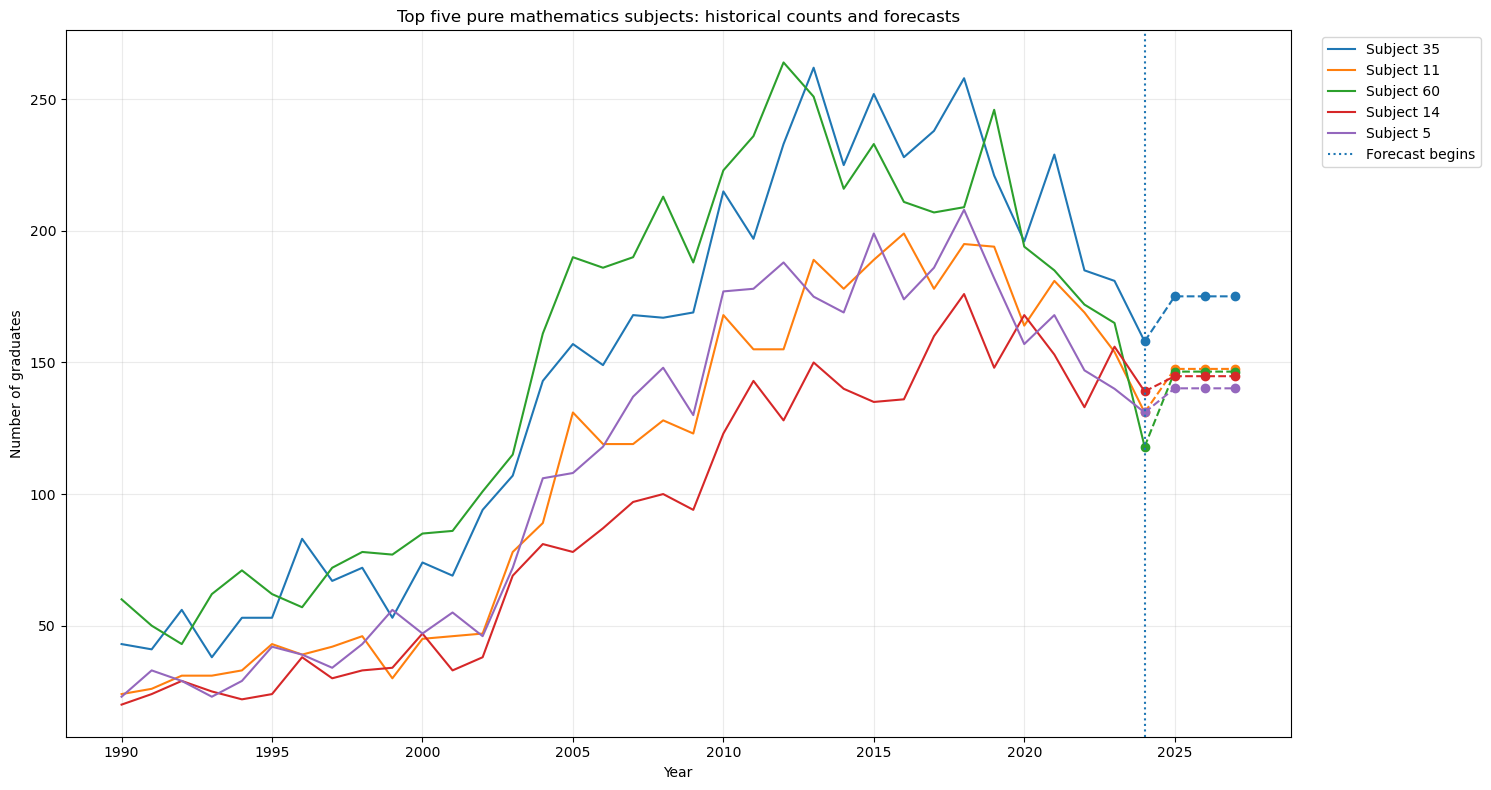

In [167]:
pure_top5_counts, pure_top5_counts_table = (
    select_top_subjects(
        forecast_matrix=pure_counts_forecast,
        top_n=5,
        ranking_method="mean"
    )
)

display(pure_top5_counts_table)

plot_top_subject_forecasts(
    historical_matrix=counts_pure,
    forecast_matrix=pure_counts_forecast,
    top_subject_codes=pure_top5_counts,
    title=(
        "Top five pure mathematics subjects: "
        "historical counts and forecasts"
    ),
    ylabel="Number of graduates",
    historical_start_year=1990
)

### 9.2 Pure mathematics: top five by share

year,rank,2025,2026,2027,average_forecast
subject_code,,,,,
35.0,1,10.170980,10.134747,10.099626,10.135118
60.0,2,9.065111,9.035276,9.006102,9.035496
14.0,3,8.293738,8.456931,8.608750,8.453140
5.0,4,8.369532,8.401594,8.432718,8.401281
11.0,5,8.306106,8.354730,8.403118,8.354651


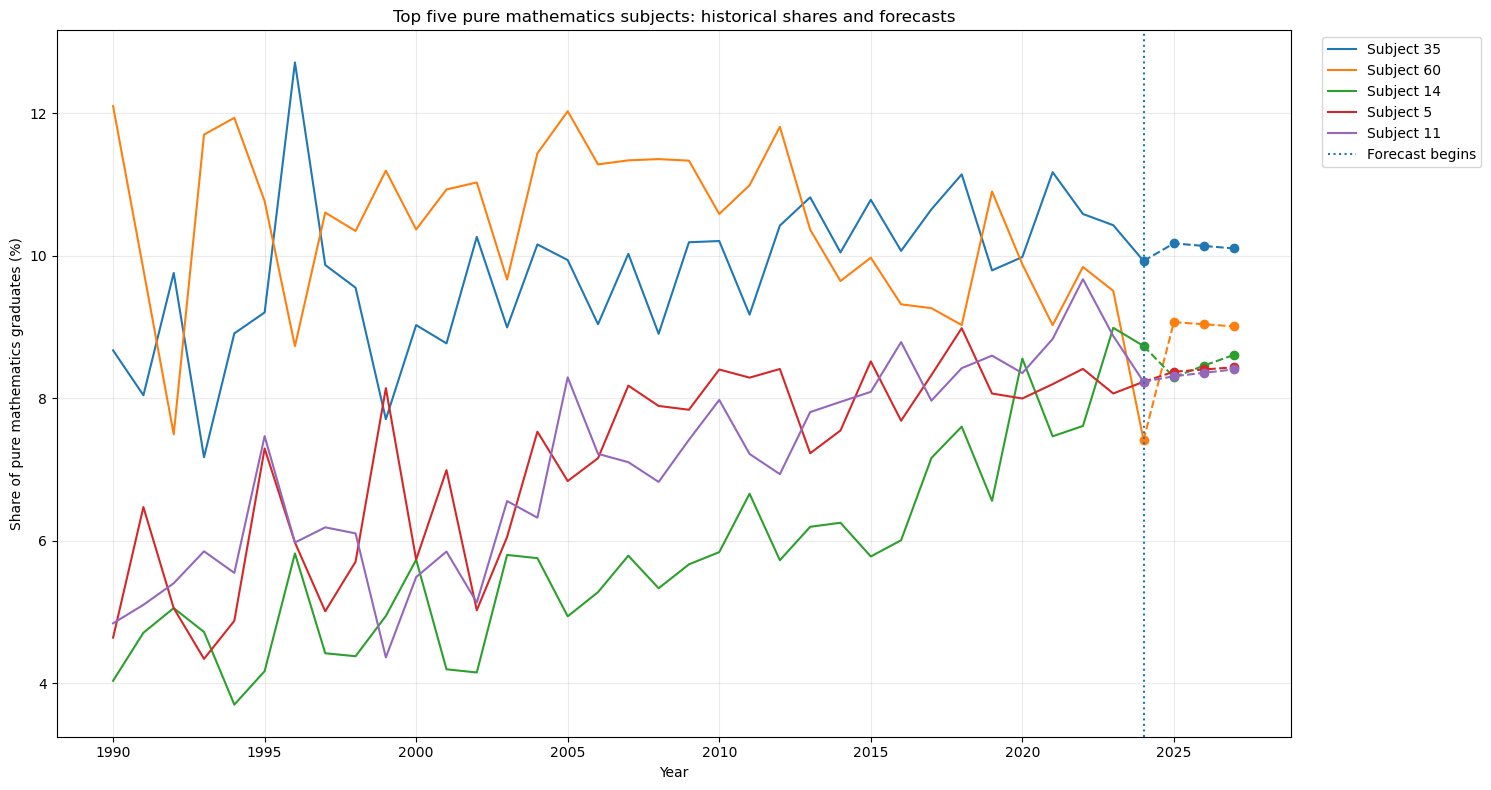

In [168]:
pure_top5_share, pure_top5_share_table = (
    select_top_subjects(
        forecast_matrix=pure_share_forecast,
        top_n=5,
        ranking_method="mean"
    )
)

display(pure_top5_share_table)

pure_share_ylabel = (
    "Share of pure mathematics graduates (%)"
    if share_pure.sum(axis=0).median() > 2
    else "Share of pure mathematics graduates"
)

plot_top_subject_forecasts(
    historical_matrix=share_pure,
    forecast_matrix=pure_share_forecast,
    top_subject_codes=pure_top5_share,
    title=(
        "Top five pure mathematics subjects: "
        "historical shares and forecasts"
    ),
    ylabel=pure_share_ylabel,
    historical_start_year=1990
)

### 9.3 Applied mathematics: top five by counts

year,rank,2025,2026,2027,average_forecast
subject_code,,,,,
68.0,1,597.421308,597.421308,597.421308,597.421308
62.0,2,407.722274,407.722274,407.722274,407.722274
65.0,3,184.963623,184.963623,184.963623,184.963623
90.0,4,118.784724,118.784724,118.784724,118.784724
91.0,5,104.112324,104.112324,104.112324,104.112324


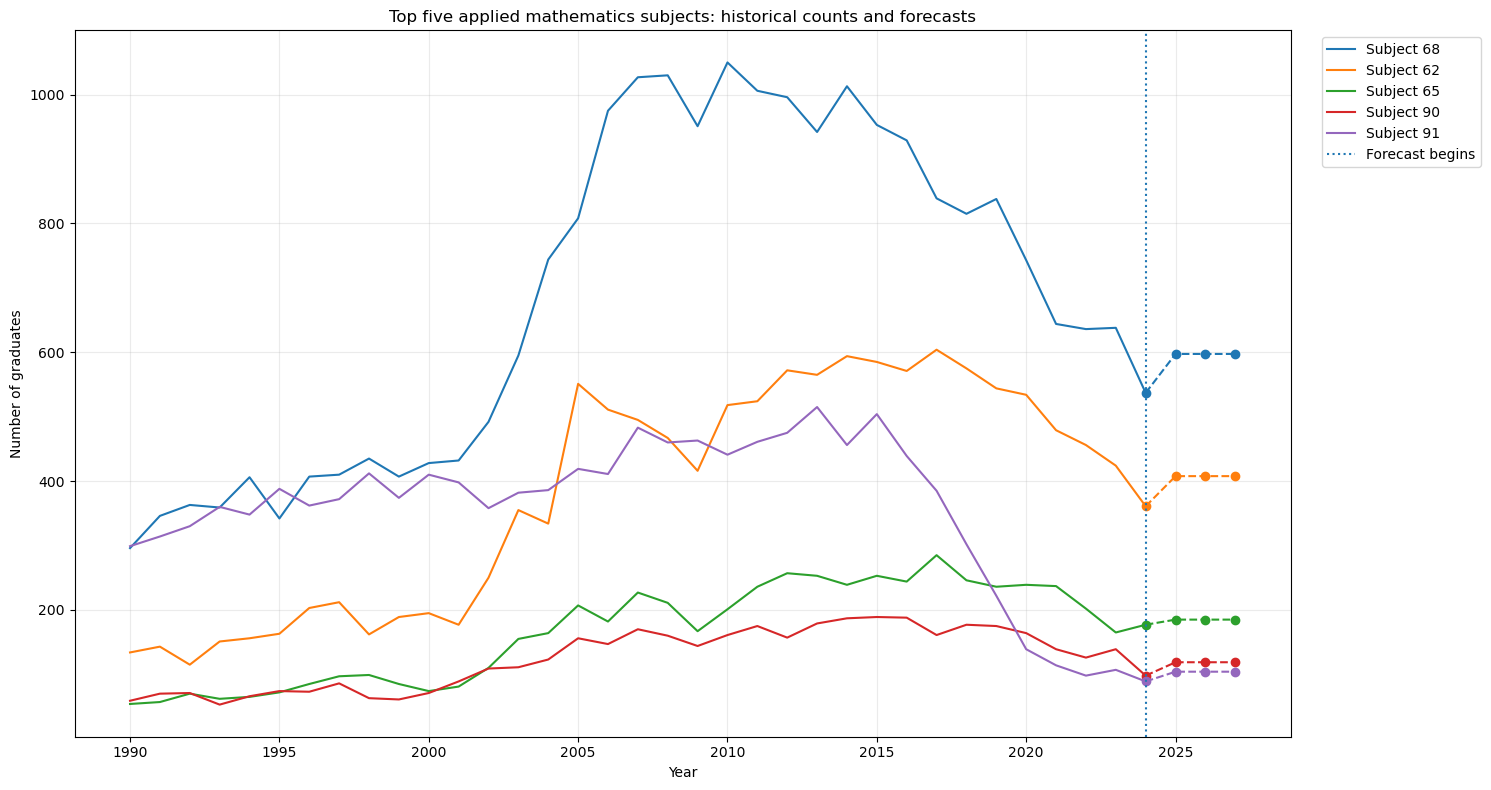

In [169]:
applied_top5_counts, applied_top5_counts_table = (
    select_top_subjects(
        forecast_matrix=applied_counts_forecast,
        top_n=5,
        ranking_method="mean"
    )
)

display(applied_top5_counts_table)

plot_top_subject_forecasts(
    historical_matrix=counts_applied,
    forecast_matrix=applied_counts_forecast,
    top_subject_codes=applied_top5_counts,
    title=(
        "Top five applied mathematics subjects: "
        "historical counts and forecasts"
    ),
    ylabel="Number of graduates",
    historical_start_year=1990
)

### 9.4 Applied mathematics: top five by share

year,rank,2025,2026,2027,average_forecast
subject_code,,,,,
68.0,1,32.059140,32.059140,32.059140,32.059140
62.0,2,21.832604,21.832604,21.832604,21.832604
65.0,3,9.968326,9.968326,9.968326,9.968326
90.0,4,6.319421,6.319421,6.319421,6.319421
91.0,5,5.484280,5.484280,5.484280,5.484280


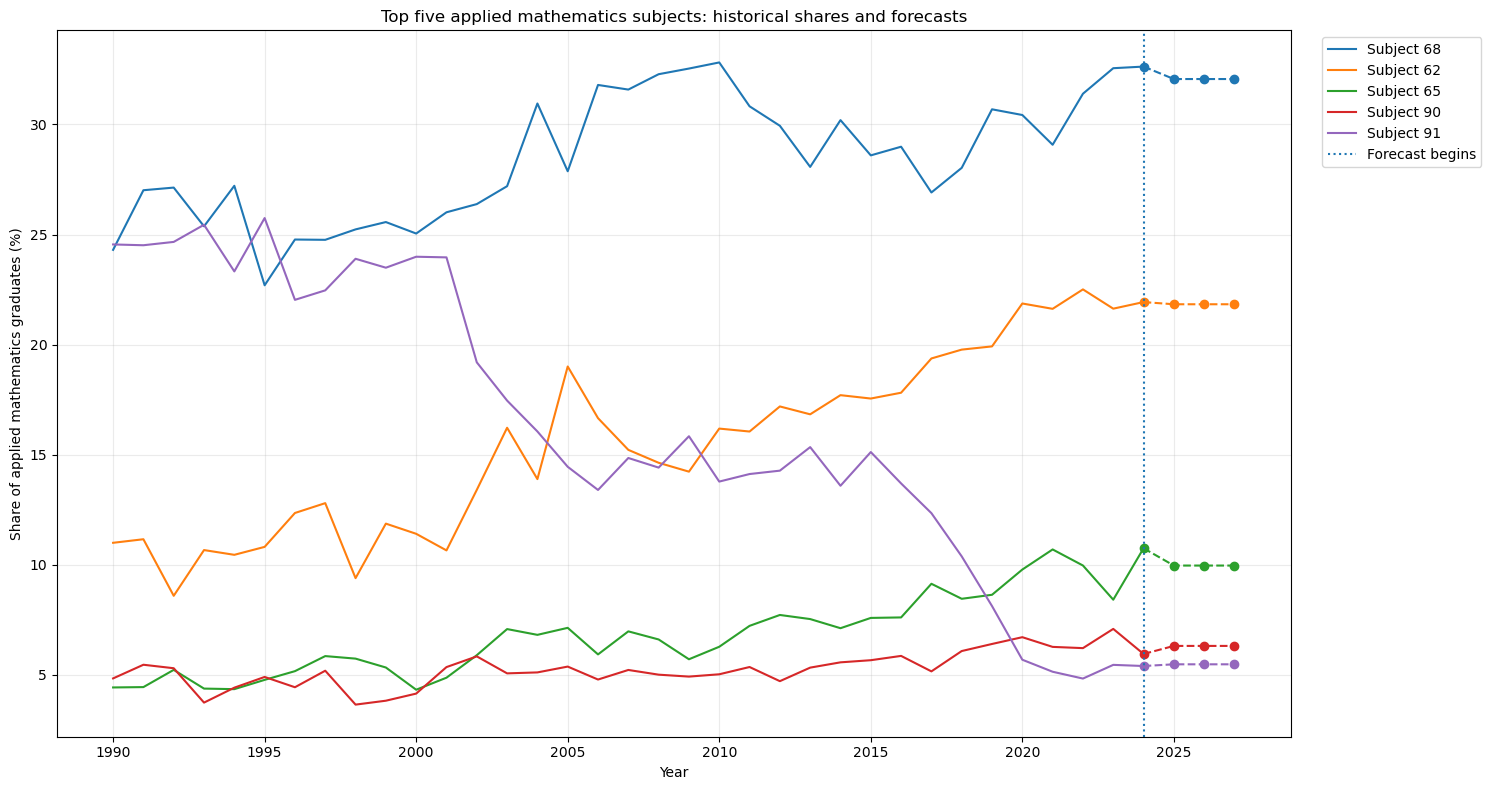

In [170]:
applied_top5_share, applied_top5_share_table = (
    select_top_subjects(
        forecast_matrix=applied_share_forecast,
        top_n=5,
        ranking_method="mean"
    )
)

display(applied_top5_share_table)

applied_share_ylabel = (
    "Share of applied mathematics graduates (%)"
    if share_applied.sum(axis=0).median() > 2
    else "Share of applied mathematics graduates"
)

plot_top_subject_forecasts(
    historical_matrix=share_applied,
    forecast_matrix=applied_share_forecast,
    top_subject_codes=applied_top5_share,
    title=(
        "Top five applied mathematics subjects: "
        "historical shares and forecasts"
    ),
    ylabel=applied_share_ylabel,
    historical_start_year=1990
)